# Level shift nelle vendite — analisi di rilevabilità

Questo notebook valuta la capacità della pipeline LSTM forecasting-based di rilevare anomalie di tipo `level_shift` al variare di intensità, direzione e durata dell’evento.

Il modello predittivo e la configurazione del detector restano fissi. La ground truth viene usata soltanto per la valutazione event-level.

## Import e dipendenze

Gli artifact sono centralizzati in `project_paths.py`. Le funzioni comuni per score, soglie, finestre e valutazione sono raccolte in `sales_level_shift_utils.py`.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm.auto import tqdm
from IPython.display import display

from project_paths import (
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    SALES_MODEL_DIR,
)

from sales_level_shift_utils import (
    classify_level_shift_severity,
    list_sensitivity_datasets,
    run_level_shift_std_detector_details,
    run_sales_lstm_inference_for_dataset,
    infer_model_window_size
)

## Configurazione e cache

La finestra del modello, i parametri del detector e le soglie operative corrispondono alla configurazione base.

Con `FORCE_RECOMPUTE = False`:
- se esiste `level_shift_severity_raw_results.csv`, l’analisi viene caricata senza rieseguire i dataset;
- in assenza del CSV aggregato, vengono riutilizzate le cache `.pkl` disponibili per i singoli dataset.

In [3]:
BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR
MODEL_DIR = SALES_MODEL_DIR

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "lstm_severity"
CACHE_DIR = OUTPUT_DIR / "_cache"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, CACHE_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Parametri fissi del detector.
SCORE_WINDOW = 7
N_STD = 3.5
MIN_CONSECUTIVE = 3
GAP_TOLERANCE = 1
IOU_THRESHOLD = 0.20

SOFT_SEVERITY_THRESHOLD = 0.05
MEDIUM_SEVERITY_THRESHOLD = 0.150
SEVERITY_CLASS_ORDER = ["soft", "medium", "hard"]

# Se True, ignora risultati salvati e cache per-dataset.
FORCE_RECOMPUTE = False

# Utile per debug veloce: ad esempio 5. Lasciare None per l'esperimento completo.
DEBUG_MAX_DATASETS = None

RAW_RESULTS_PATH = OUTPUT_DIR / "level_shift_severity_raw_results.csv"

## Modello LSTM e artifact di preprocessing

Vengono caricati il modello sales selezionato e gli artifact necessari per ricostruire gli input: scaler per store, mapping categorici e schema delle feature.

In [4]:
model = tf.keras.models.load_model(
    MODEL_DIR / "lstm_sales.keras"
)

# Finestra usata dal modello predittivo LSTM.
MODEL_WINDOW_SIZE = infer_model_window_size(model)
print("Window size del modello caricato:", MODEL_WINDOW_SIZE)

with open(MODEL_DIR / "feature_scalers.pkl", "rb") as f:
    feature_scalers = pickle.load(f)

with open(MODEL_DIR / "mappings.pkl", "rb") as f:
    mappings = pickle.load(f)

with open(MODEL_DIR / "features.pkl", "rb") as f:
    features = pickle.load(f)
    
features

Window size del modello caricato: 28


{'seq_num': ['daily_total_sales'],
 'seq_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'seq_cat': ['week_day', 'month', 'day'],
 'final_num': ['time_idx', 'oil_price', 'consumer_confidence', 'fao'],
 'final_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'cat': ['store_id', 'week_day', 'month', 'day'],
 'ground_truth': ['is_level_shift_anomaly',
  'lsa_type',
  'lsa_mult',
  'lsa_severity',
  'lsa_event_id',
  'lsa_day_in_event',
  'lsa_duration',
  'is_weekday_contextual_anomaly',
  'wca_type',
  'wca_ratio',
  'wca_event_id',
  'wca_day_in_event',
  'wca_duration'],
 'target': 'daily_total_sales',
 'log_transform': ['daily_total_sales', 'oil_price', 'fao'],
 'scale': ['daily_total_sales',
  'time_idx',
  'oil_price',
  'consumer_confidence',
  'fao']}

## Dataset di sensitivity

Ogni dataset identifica una combinazione di direzione, durata, moltiplicatore e seed. Le anomalie sono presenti nel test; train e validation restano il riferimento per la previsione del comportamento ordinario e per la calibrazione delle soglie.

In [5]:
datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset:", len(datasets_df))
datasets_df.head()

Numero dataset: 280


,path,direction,duration,multiplier,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46


## Valutazione di un singolo dataset

Per ogni dataset vengono eseguite inference su validation e test, aggregazione dei residui in uno score, calibrazione delle soglie per store sulla validation e valutazione delle finestre rilevate nel test.

La costruzione delle finestre rilevate usa `build_detected_windows_from_center_points`, centralizzata in `sales_level_shift_utils.py`.

In [6]:
def evaluate_single_level_shift_dataset(
    csv_path,
    direction,
    duration,
    multiplier,
    seed,
):
    inference = run_sales_lstm_inference_for_dataset(
        csv_path=csv_path,
        model=model,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=MODEL_WINDOW_SIZE,
    )

    val_results = inference["val_results"]
    test_results = inference["test_results"]

    # La validation dovrebbe contenere solo comportamento ordinario.
    if "is_level_shift_anomaly" in val_results.columns:
        n_val_anom = int(val_results["is_level_shift_anomaly"].sum())
        if n_val_anom > 0:
            print(f"Warning: validation contiene {n_val_anom} punti level_shift.")

    detector_output = run_level_shift_std_detector_details(
        val_results=val_results,
        test_results=test_results,
        score_window=SCORE_WINDOW,
        n_std=N_STD,
        min_consecutive=MIN_CONSECUTIVE,
        gap_tolerance=GAP_TOLERANCE,
        iou_threshold=IOU_THRESHOLD,
    )

    # L'esperimento salva la sintesi; le finestre dettagliate non servono alle aggregazioni successive.
    summary = detector_output["summary"].copy()

    severity_class = classify_level_shift_severity(
        multiplier,
        soft_threshold=SOFT_SEVERITY_THRESHOLD,
        medium_threshold=MEDIUM_SEVERITY_THRESHOLD,
    )

    summary.update({
        "direction": direction,
        "duration": int(duration),
        "multiplier": float(multiplier),
        "severity_class": severity_class,
        "seed": int(seed),
    })

    return summary

## Esecuzione dell’analisi e cache per dataset

Il CSV dei risultati completi ha priorità sulle cache per dataset. Le cache `.pkl` consentono di riprendere un’esecuzione interrotta senza ripetere i dataset già elaborati.

In [7]:
def make_dataset_cache_path(row):
    multiplier_str = str(row["multiplier"]).replace(".", "p")

    filename = (
        f"{row['direction']}"
        f"_dur_{int(row['duration'])}"
        f"_mult_{multiplier_str}"
        f"_seed_{int(row['seed'])}"
        ".pkl"
    )

    return CACHE_DIR / filename


# Il CSV finale evita qualsiasi ricalcolo; le cache per dataset servono solo a riprendere run interrotti.
if RAW_RESULTS_PATH.exists() and not FORCE_RECOMPUTE:
    print(f"Carico risultati già calcolati: {RAW_RESULTS_PATH}")
    severity_results = pd.read_csv(RAW_RESULTS_PATH)

else:
    results = []
    start_time = time.time()

    for _, row in tqdm(datasets_df.iterrows(), total=len(datasets_df)):

        cache_path = make_dataset_cache_path(row)

        # Riusa il risultato del singolo dataset solo quando manca il CSV finale.
        if cache_path.exists() and not FORCE_RECOMPUTE:
            with open(cache_path, "rb") as f:
                summary = pickle.load(f)
        else:
            summary = evaluate_single_level_shift_dataset(
                csv_path=row["path"],
                direction=row["direction"],
                duration=row["duration"],
                multiplier=row["multiplier"],
                seed=row["seed"],
            )

            with open(cache_path, "wb") as f:
                pickle.dump(summary, f)

        results.append(summary)

    severity_results = pd.DataFrame(results)
    severity_results.to_csv(RAW_RESULTS_PATH, index=False)

    elapsed = time.time() - start_time
    print(f"Analisi completata in {elapsed / 60:.1f} minuti.")

print(severity_results.shape)
severity_results.head()

Carico risultati già calcolati: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_severity\level_shift_severity_raw_results.csv
(280, 16)


,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end,direction,duration,multiplier,severity_class,seed
0,40,66,40,26,0,0.606061,1.0,0.754717,0.447984,-5.625,3.050,decrease,7,0.7,hard,42
1,40,63,40,23,0,0.634921,1.0,0.776699,0.443395,-5.675,3.300,decrease,7,0.7,hard,43
2,40,64,40,24,0,0.625000,1.0,0.769231,0.440574,-5.750,3.300,decrease,7,0.7,hard,44
3,40,61,40,21,0,0.655738,1.0,0.792079,0.446315,-5.725,3.075,decrease,7,0.7,hard,45
4,40,66,40,26,0,0.606061,1.0,0.754717,0.450116,-5.750,2.850,decrease,7,0.7,hard,46


## Aggregazione per severità

Le metriche vengono calcolate con conteggi pooled. La IoU media è ricostruita sommando le IoU dei true positive e dividendo per il loro numero complessivo.

In [8]:
severity_results = severity_results.copy()

# Somma delle IoU dei true positive per ciascun run.
# mean_iou è definita sui soli true positive.
severity_results["sum_iou"] = (
    severity_results["mean_iou"] * severity_results["tp"]
)

severity_class_summary = (
    severity_results
    .groupby(["direction", "severity_class"], as_index=False)
    .agg(
        n_gt_events=("n_gt_events", "sum"),
        n_detected_events=("n_detected_events", "sum"),
        tp=("tp", "sum"),
        fp=("fp", "sum"),
        fn=("fn", "sum"),
        sum_iou=("sum_iou", "sum"),
    )
)

severity_class_summary["precision"] = (
    severity_class_summary["tp"] /
    (severity_class_summary["tp"] + severity_class_summary["fp"])
)

severity_class_summary["recall"] = (
    severity_class_summary["tp"] /
    (severity_class_summary["tp"] + severity_class_summary["fn"])
)

den = severity_class_summary["precision"] + severity_class_summary["recall"]

severity_class_summary["f1"] = np.where(
    den > 0,
    2
    * severity_class_summary["precision"]
    * severity_class_summary["recall"]
    / den,
    np.nan,
)

severity_class_summary["mean_iou"] = np.where(
    severity_class_summary["tp"] > 0,
    severity_class_summary["sum_iou"] / severity_class_summary["tp"],
    np.nan,
)

severity_class_summary = severity_class_summary.drop(columns=["sum_iou"])

severity_class_summary["severity_class"] = pd.Categorical(
    severity_class_summary["severity_class"],
    categories=SEVERITY_CLASS_ORDER,
    ordered=True,
)

severity_class_summary = (
    severity_class_summary
    .sort_values(["direction", "severity_class"])
    .reset_index(drop=True)
)

severity_class_summary["severity_class"] = (
    severity_class_summary["severity_class"].astype(str)
)

# Riga pooled su tutti i risultati.
total_tp = severity_class_summary["tp"].sum()
total_fp = severity_class_summary["fp"].sum()
total_fn = severity_class_summary["fn"].sum()

total_precision = total_tp / (total_tp + total_fp)
total_recall = total_tp / (total_tp + total_fn)

total_f1 = (
    2 * total_precision * total_recall / (total_precision + total_recall)
    if total_precision + total_recall > 0
    else np.nan
)

total_sum_iou = (
    severity_results["mean_iou"] * severity_results["tp"]
).sum()

total_mean_iou = (
    total_sum_iou / total_tp
    if total_tp > 0
    else np.nan
)

total_row = pd.DataFrame([{
    "direction": "overall",
    "severity_class": "overall",
    "n_gt_events": severity_class_summary["n_gt_events"].sum(),
    "n_detected_events": severity_class_summary["n_detected_events"].sum(),
    "tp": total_tp,
    "fp": total_fp,
    "fn": total_fn,
    "precision": total_precision,
    "recall": total_recall,
    "f1": total_f1,
    "mean_iou": total_mean_iou,
}])

severity_class_summary = pd.concat(
    [severity_class_summary, total_row],
    ignore_index=True,
)

severity_class_summary = severity_class_summary[
    [
        "direction",
        "severity_class",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision",
        "recall",
        "f1",
        "mean_iou",
    ]
]

severity_class_summary.to_csv(
    TABLES_DIR / "level_shift_severity_class_summary.csv",
    index=False,
)

severity_class_summary

,direction,severity_class,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou
0,decrease,soft,1600,191,106,85,1494,0.554974,0.066250,0.118370,0.610884
1,decrease,medium,2400,2033,1710,323,690,0.841121,0.712500,0.771487,0.670233
2,decrease,hard,1600,2346,1600,746,0,0.682012,1.000000,0.810948,0.615972
3,increase,soft,1600,521,427,94,1173,0.819578,0.266875,0.402640,0.604998
4,increase,medium,2400,2354,2158,196,242,0.916737,0.899167,0.907867,0.665690
5,increase,hard,1600,1766,1600,166,0,0.906002,1.000000,0.950683,0.610987
6,overall,overall,11200,9211,7601,1610,3599,0.825209,0.678661,0.744794,0.640558


## Aggregazione per moltiplicatore

I risultati sono raggruppati per direzione, durata e moltiplicatore per descrivere l’andamento delle metriche al variare dell’intensità dello shift.

In [9]:
# Le metriche pooled vengono calcolate dopo l'aggregazione dei conteggi per run.
metric_summary = (
    severity_results
    .groupby(["direction", "duration", "multiplier"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        n_gt_events=("n_gt_events", "sum"),
        n_detected_events=("n_detected_events", "sum"),
        tp=("tp", "sum"),
        fp=("fp", "sum"),
        fn=("fn", "sum"),
    )
)

metric_summary["precision_pooled"] = (
    metric_summary["tp"] /
    (metric_summary["tp"] + metric_summary["fp"])
)

metric_summary["recall_pooled"] = (
    metric_summary["tp"] /
    (metric_summary["tp"] + metric_summary["fn"])
)

metric_summary["f1_pooled"] = (
    2
    * metric_summary["precision_pooled"]
    * metric_summary["recall_pooled"]
    / (
        metric_summary["precision_pooled"]
        + metric_summary["recall_pooled"]
    )
)

metric_summary = (
    metric_summary
    .sort_values(["direction", "duration", "multiplier"])
    .reset_index(drop=True)
)

metric_summary.to_csv(
    TABLES_DIR / "level_shift_metric_summary_by_multiplier.csv",
    index=False,
)

metric_summary.head()

,direction,duration,multiplier,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,decrease,7,0.700,5,200,320,200,120,0,0.625000,1.000,0.769231
1,decrease,7,0.800,5,200,262,200,62,0,0.763359,1.000,0.865801
2,decrease,7,0.850,5,200,238,199,39,1,0.836134,0.995,0.908676
3,decrease,7,0.900,5,200,148,130,18,70,0.878378,0.650,0.747126
4,decrease,7,0.925,5,200,68,56,12,144,0.823529,0.280,0.417910


## Grafici delle metriche

Per ogni durata, i tratti relativi a riduzioni e aumenti mantengono lo stesso colore. I grafici vengono salvati in `figures/`.

In [10]:
def plot_metric_by_multiplier(
    metric_summary,
    metric,
    figures_dir=None,
    filename=None,
    title=None,
    y_label=None,
    figsize=(10, 6),
    linewidth=2.2,
    marker_size=5,
    show=True
):
    """
    Crea un lineplot per una metrica pooled.

    Asse x:
        moltiplicatore m.

    Linee:
        una linea per ciascuna durata.
    """

    metric_value = f"{metric}_pooled"

    if metric_value not in metric_summary.columns:
        raise ValueError(f"Colonna mancante: {metric_value}")

    if title is None:
        title = f"{metric.upper()} al variare del moltiplicatore"

    if y_label is None:
        y_label = metric.upper()

    def format_multiplier_tick(x):
        return f"{x:.3f}".rstrip("0").rstrip(".")

    fig, ax = plt.subplots(figsize=figsize)

    durations = sorted(metric_summary["duration"].unique())

    for duration in durations:

        temp_duration = (
            metric_summary[metric_summary["duration"] == duration]
            .sort_values("multiplier")
            .copy()
        )

        decrease_part = (
            temp_duration[temp_duration["direction"].eq("decrease")]
            .sort_values("multiplier")
        )

        increase_part = (
            temp_duration[temp_duration["direction"].eq("increase")]
            .sort_values("multiplier")
        )

        color = None

        if not decrease_part.empty:
            line, = ax.plot(
                decrease_part["multiplier"],
                decrease_part[metric_value],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                label=f"{duration} giorni"
            )

            color = line.get_color()

        if not increase_part.empty:
            ax.plot(
                increase_part["multiplier"],
                increase_part[metric_value],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                color=color,
                label=None if color is not None else f"{duration} giorni"
            )

    ax.set_title(title)
    ax.set_xlabel("Moltiplicatore")
    ax.set_ylabel(y_label)
    ax.set_ylim(-0.05, 1.05)

    xticks = sorted(metric_summary["multiplier"].unique())

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [format_multiplier_tick(x) for x in xticks],
        rotation=45
    )

    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="Durata eventi GT")

    plt.tight_layout()

    if figures_dir is not None:
        figures_dir = Path(figures_dir)
        figures_dir.mkdir(parents=True, exist_ok=True)

        if filename is None:
            filename = f"level_shift_{metric}_by_multiplier.png"

        fig.savefig(
            figures_dir / filename,
            dpi=300,
            bbox_inches="tight"
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

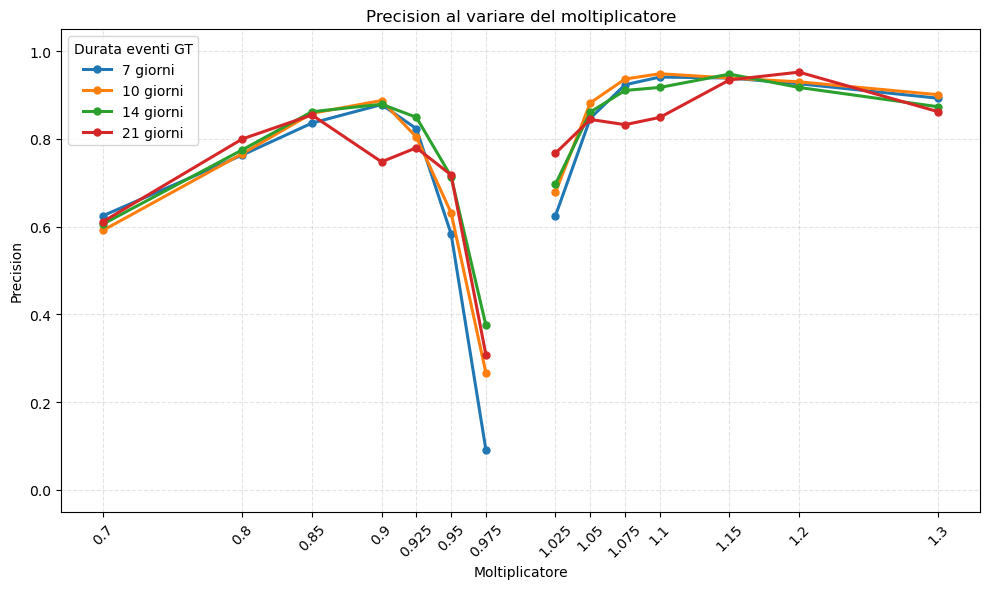

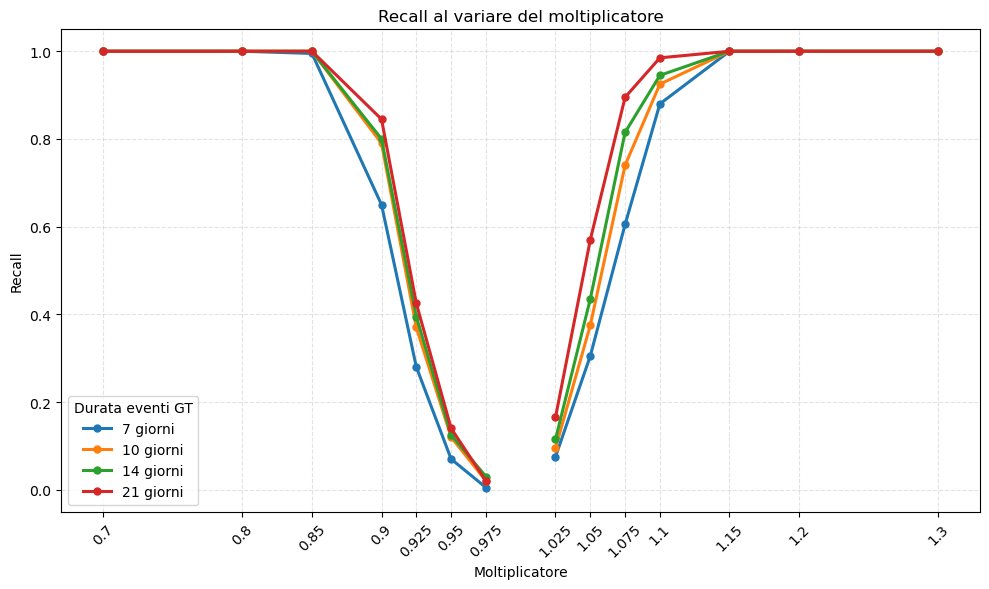

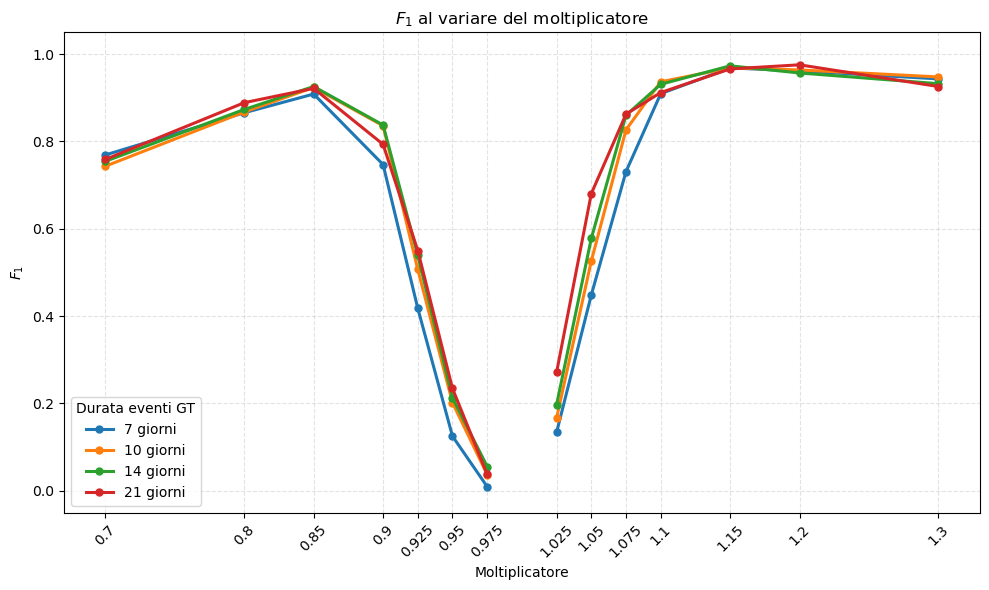

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': '$F_1$ al variare del moltiplicatore'}, xlabel='Moltiplicatore', ylabel='$F_1$'>)

In [11]:
plot_metric_by_multiplier(
    metric_summary=metric_summary,
    metric="precision",
    figures_dir=FIGURES_DIR,
    filename="level_shift_precision_by_multiplier.png",
    title="Precision al variare del moltiplicatore",
    y_label="Precision",
)

plot_metric_by_multiplier(
    metric_summary=metric_summary,
    metric="recall",
    figures_dir=FIGURES_DIR,
    filename="level_shift_recall_by_multiplier.png",
    title="Recall al variare del moltiplicatore",
    y_label="Recall",
)

plot_metric_by_multiplier(
    metric_summary=metric_summary,
    metric="f1",
    figures_dir=FIGURES_DIR,
    filename="level_shift_f1_by_multiplier.png",
    title=r"$F_1$ al variare del moltiplicatore",
    y_label=r"$F_1$",
)

## Esportazione delle figure

In [12]:
FIGURES_DIR

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/lstm_severity/figures')